In [20]:
import pathlib
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from prepare import process_regressor, model_performance_metrics,draw_scatter
from data_prune_function import get_scores,get_data,prune_rd,return_model

test_size = 0.1

model = {}
for modelname in ['CB','XG','GB']:
    model[modelname] = return_model(modelname,random_state=1)

target = 'NO(%)'
df,X,y,X_train_val,X_test,y_train_val,y_test = get_data(target = target,random_state=27, test_size=test_size,standardized=False)
mad = (y - y.mean()).abs().mean()
std = y.std()
print('')
print('-----------------')
print(f'{target} {y.shape[0]} {mad:.3f} {std:.3f} ')
print('-----------------')
target = 'NO(%)'
a = 'CB'
b = 'XG'
c = 'GB'


-----------------
NO(%) 242 14.156 17.853 
-----------------


In [24]:
folder = f'{target}/{target}_{a}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_a = f'{folder}/all_dat.pkl'

folder = f'{target}/{target}_{b}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_b = f'{folder}/all_dat.pkl'

folder = f'{target}/{target}_{c}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_c = f'{folder}/all_dat.pkl'

In [25]:
maes_a, rmse_a, r2_a = get_scores(model[a], X_train_val, y_train_val, X_test, y_test)
maes_b, rmse_b, r2_b = get_scores(model[b], X_train_val, y_train_val, X_test, y_test)
maes_c, rmse_c, r2_c = get_scores(model[c], X_train_val, y_train_val, X_test, y_test)

Test scores: MAE=5.401, RMSE=6.642, R2=0.852
--- 0.6712183952331543 seconds ---

Test scores: MAE=5.299, RMSE=6.769, R2=0.846
--- 0.08756470680236816 seconds ---

Test scores: MAE=4.914, RMSE=6.527, R2=0.857
--- 0.11228156089782715 seconds ---



In [26]:
from prepare import get_mse_rmse_mae_mape_smape_r2
import os
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

def draw_scatter_1(train_true, train_pred, val_true, val_pred,
                   test_true, test_pred, title,
                   test_lower=None, test_upper=None,
                   actual_text='actual', pred_text='prediction',
                   save=False):
    """
    绘制三组数据的散点图（训练集、验证集、测试集）
    仅在测试集上添加误差区间和误差棒
    """

    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'

    # 转成一维数组，避免 pandas / ndarray 混用出错
    train_true = np.asarray(train_true).ravel()
    train_pred = np.asarray(train_pred).ravel()
    val_true = np.asarray(val_true).ravel()
    val_pred = np.asarray(val_pred).ravel()
    test_true = np.asarray(test_true).ravel()
    test_pred = np.asarray(test_pred).ravel()

    if test_lower is not None:
        test_lower = np.asarray(test_lower).ravel()
    if test_upper is not None:
        test_upper = np.asarray(test_upper).ravel()

    # 创建图形
    fig, ax = plt.subplots(figsize=(10, 8))

    # 定义字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',
        'weight': 'bold',
        'size': 18
    }
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}

    # ===== 先画训练集、验证集回归散点图（基础内容不变）=====
    sns.regplot(x=train_true, y=train_pred,
                color="dodgerblue", label='train',
                scatter_kws={'alpha': 0.5, 's': 18},
                ax=ax)

    sns.regplot(x=val_true, y=val_pred,
                color="orange", label="val",
                scatter_kws={'alpha': 0.5, 's': 10},
                ax=ax)

    sns.regplot(x=test_true, y=test_pred,
                color='#FF69B4', label='test',
                scatter_kws={'alpha': 0.8, 's': 30},
                ax=ax)

    # ===== 只对测试集添加误差区间和误差棒 =====
    if test_lower is not None and test_upper is not None:
        # 按真实值排序，保证阴影区间平滑
        sorted_idx = np.argsort(test_true)
        test_true_sorted = test_true[sorted_idx]
        test_pred_sorted = test_pred[sorted_idx]
        lower_sorted = test_lower[sorted_idx]
        upper_sorted = test_upper[sorted_idx]

        # 计算误差棒上下长度
        yerr_lower = np.maximum(test_pred_sorted - lower_sorted, 0)
        yerr_upper = np.maximum(upper_sorted - test_pred_sorted, 0)

        # 置信区间阴影
        ax.fill_between(
            test_true_sorted,
            lower_sorted,
            upper_sorted,
            color='lightgray',
            alpha=0.5,
            label='95% Confidence Interval',
            zorder=1
        )

        # 误差棒
        ax.errorbar(
            test_true_sorted,
            test_pred_sorted,
            yerr=[yerr_lower, yerr_upper],
            fmt='o',
            markersize=4,
            color='#FF69B4',
            ecolor='gray',
            elinewidth=1,
            capsize=3,
            alpha=0.7,
            zorder=2
        )

    # ===== 坐标轴标签和范围 =====
    ax.set_xlabel(actual_text, fontdict=font_common, weight='bold')
    ax.set_ylabel(pred_text, fontdict=font_common, weight='bold')
    ax.set_xlim(15, 95)
    ax.set_ylim(15, 95)

    # 图例
    ax.legend(loc="lower right", markerscale=1.5, prop=legend_font,
              frameon=True)

    # 刻度
    ax.tick_params(axis='both', which='major', direction='out',
                   width=2, labelsize=16,
                   bottom=True, top=False, left=True, right=False)
    ax.tick_params(axis='both', which='minor', direction='out',
                   bottom=True, top=False, left=True, right=False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(16)      # 放大字体
        label.set_fontweight('bold')  # 加粗
        label.set_family('Times New Roman')
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(10))

    # 背景和边框
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_linewidth(3)
        spine.set_edgecolor('black')

    # 网格
    ax.grid(True, axis='both', linestyle='--',
            linewidth=0.5, color='gray', alpha=0.6)

    # ===== 统计信息 =====
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(
        train_true / 100, train_pred / 100
    )
    _, _, _, _, _, val_r2 = get_mse_rmse_mae_mape_smape_r2(
        val_true / 100, val_pred / 100
    )
    _, _, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(
        test_true / 100, test_pred / 100
    )

    ax.text(20, 86, f"Train R² = {train_r2:.3f}", **font_common)
    ax.text(20, 80, f"val   R² = {val_r2:.3f}", **font_common)
    ax.text(20, 74, f"test  R² = {test_r2:.3f}", **font_common)

    # 标题
    ax.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存
    if save:
        out_put = 'prune4'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")

    plt.tight_layout()
    plt.show()

In [27]:
size_old_val_a, ids_a, test_scores_a, val_scores_a,test_fit_a,remove_a = prune_rd(
        model[a], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,
        threshold=maes_a / 2,train_size= 0.9, file_out=file_out_a)

Iteration 0:
丢弃训练词条数量 : 6 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.6428086757659912 seconds ---
修剪模型：
Test scores: maes=5.518, rmse=6.837, r2=0.843
--- 0.8293468952178955 seconds ---
Iteration 1:
丢弃训练词条数量 : 6 
本次循环中 old_val 数量: 6 (ratio = 0.028)
本次循环中新训练集大小，占比: 211  (ratio = 0.972)
--- 0.6416707038879395 seconds ---
修剪模型：
Test scores: maes=5.695, rmse=7.052, r2=0.833
Val scores: maes=1.598, rmse=1.767, r2=0.991
--- 0.6587095260620117 seconds ---
Iteration 2:
丢弃训练词条数量 : 6 
本次循环中 old_val 数量: 12 (ratio = 0.055)
本次循环中新训练集大小，占比: 205  (ratio = 0.945)
--- 0.6574110984802246 seconds ---
修剪模型：
Test scores: maes=5.519, rmse=6.677, r2=0.850
Val scores: maes=1.973, rmse=2.300, r2=0.974
--- 0.6744883060455322 seconds ---
Iteration 3:
丢弃训练词条数量 : 3 
本次循环中 old_val 数量: 18 (ratio = 0.083)
本次循环中新训练集大小，占比: 199  (ratio = 0.917)
--- 0.6617677211761475 seconds ---
修剪模型：
Test scores: maes=5.375, rmse=6.793, r2=0.845
Val scores: maes=1.883, rmse=2.284, r2=0.970
--- 0.6805

In [28]:
size_old_val_b, ids_b, test_scores_b, val_scores_b,test_fit_b,remove_b = prune_rd(
    model[b], X_train_val, y_train_val, X_test, y_test,max_iter=80,min_drop= 2,threshold=maes_b / 2,train_size= 0.9, file_out=file_out_b)

Iteration 0:
丢弃训练词条数量 : 7 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.10425186157226562 seconds ---
修剪模型：
Test scores: maes=5.696, rmse=7.402, r2=0.816
--- 0.08680248260498047 seconds ---
Iteration 1:
丢弃训练词条数量 : 5 
本次循环中 old_val 数量: 7 (ratio = 0.032)
本次循环中新训练集大小，占比: 210  (ratio = 0.968)
--- 0.09218811988830566 seconds ---
修剪模型：
Test scores: maes=5.669, rmse=6.881, r2=0.841
Val scores: maes=2.234, rmse=2.679, r2=0.799
--- 0.1035301685333252 seconds ---
Iteration 2:
丢弃训练词条数量 : 2 
本次循环中 old_val 数量: 12 (ratio = 0.055)
本次循环中新训练集大小，占比: 205  (ratio = 0.945)
--- 0.09317255020141602 seconds ---
修剪模型：
Test scores: maes=6.042, rmse=7.696, r2=0.801
Val scores: maes=2.480, rmse=2.927, r2=0.963
--- 0.0952446460723877 seconds ---
Iteration 3:
丢弃训练词条数量 : 3 
本次循环中 old_val 数量: 14 (ratio = 0.065)
本次循环中新训练集大小，占比: 203  (ratio = 0.935)
--- 0.09208250045776367 seconds ---
修剪模型：
Test scores: maes=5.797, rmse=7.218, r2=0.825
Val scores: maes=1.945, rmse=2.384, r2=0.972
--- 0

In [29]:
size_old_val_c, ids_c, test_scores_c, val_scores_c,test_fit_c,remove_c = prune_rd(
        model[c], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,threshold=maes_c / 2,train_size= 0.9, file_out=file_out_c)

Iteration 0:
丢弃训练词条数量 : 5 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.11453509330749512 seconds ---
修剪模型：
Test scores: maes=4.931, rmse=6.467, r2=0.859
--- 0.11820220947265625 seconds ---
Iteration 1:
丢弃训练词条数量 : 5 
本次循环中 old_val 数量: 5 (ratio = 0.023)
本次循环中新训练集大小，占比: 212  (ratio = 0.977)
--- 0.10798001289367676 seconds ---
修剪模型：
Test scores: maes=5.429, rmse=6.682, r2=0.850
Val scores: maes=1.414, rmse=1.455, r2=0.991
--- 0.11246132850646973 seconds ---
Iteration 2:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 10 (ratio = 0.046)
本次循环中新训练集大小，占比: 207  (ratio = 0.954)
--- 0.10065126419067383 seconds ---
修剪模型：
Test scores: maes=4.841, rmse=5.951, r2=0.881
Val scores: maes=1.187, rmse=1.456, r2=0.986
--- 0.1081550121307373 seconds ---
Iteration 3:
丢弃训练词条数量 : 2 
本次循环中 old_val 数量: 14 (ratio = 0.065)
本次循环中新训练集大小，占比: 203  (ratio = 0.935)
--- 0.09774136543273926 seconds ---
修剪模型：
Test scores: maes=4.915, rmse=6.103, r2=0.875
Val scores: maes=1.532, rmse=1.853, r2=0.981
--- 

In [31]:
a_test_70 = list(set(ids_a['train_val']) - set(remove_a[19]))
b_test_70 = list(set(ids_b['train_val']) - set(remove_b[22]))
c_test_70 = list(set(ids_c['train_val']) - set(remove_c[19]))

Cat Train 70% mse: 0.00007 | rmse: 0.00865 | mae: 0.00684 | mape: 1.72483 | smape: 1.71565 | r2: 0.99782

Cat val 30% mse: 0.00126 | rmse: 0.03556 | mae: 0.02980 | mape: 8.09152 | smape: 7.89930 | r2: 0.95197

Cat test mse: 0.00445 | rmse: 0.06674 | mae: 0.05428 | mape: 17.29854 | smape: 15.07645 | r2: 0.85018

测试图已保存：prune4\Catboost prune 70%.jpg


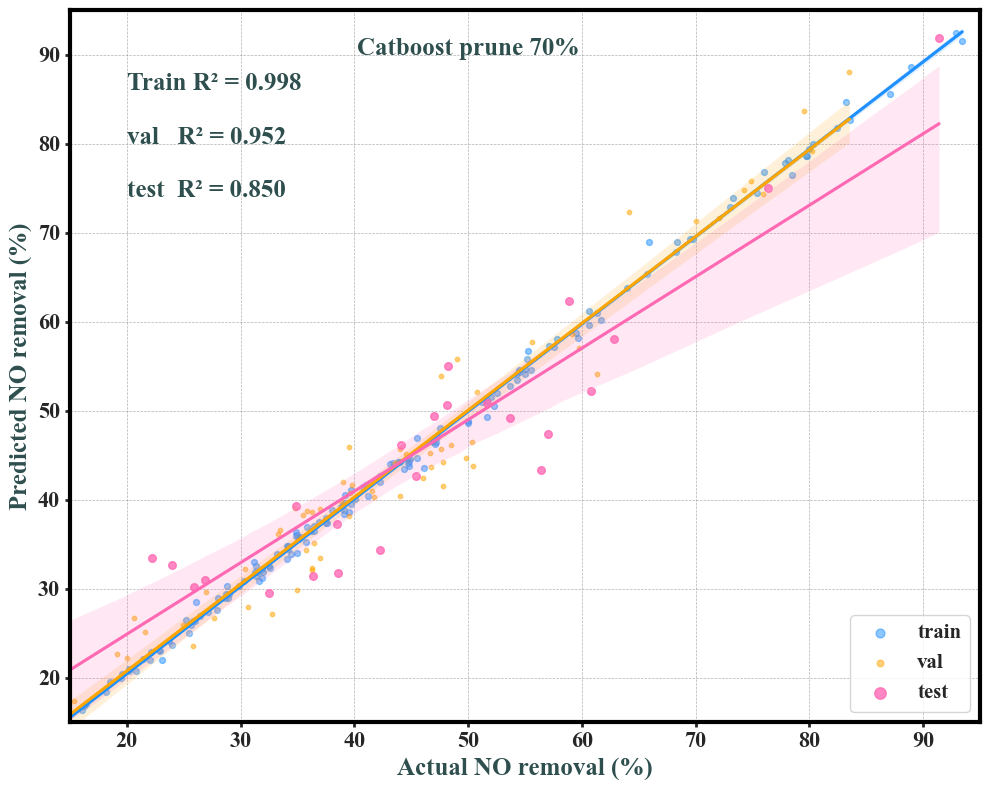

In [32]:
df_a = df.loc[remove_a[19]]
X_train_val = df_a.drop(columns=['NO(%)'])
y_train_val = df_a['NO(%)']
df_a_val = df.loc[a_test_70]
X_val = df_a_val.drop(columns=['NO(%)'])
y_val = df_a_val['NO(%)']
train_pred, val_pred = process_regressor(model[a],X_train_val,X_val,y_train_val,y_val,cv=False)
_,test_pred = process_regressor(model[a],X_train_val,X_test,y_train_val,y_test,cv=False)
model_performance_metrics('Cat Train 70%', y_train_val, train_pred)
model_performance_metrics('Cat val 30%', y_val, val_pred)
model_performance_metrics('Cat test', y_test, test_pred)
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "Catboost prune 70%", actual_text='Actual NO removal (%)',test_lower=None,test_upper=None,pred_text='Predicted NO removal (%)',save=True)

cv train R2: -0.167 (+/- 0.386) 

cv train R2: -0.167 (+/- 0.386) 

XGB Train 70% mse: 0.00048 | rmse: 0.02195 | mae: 0.01701 | mape: 4.24640 | smape: 4.17975 | r2: 0.98638

XGB val 30% mse: 0.00134 | rmse: 0.03656 | mae: 0.02897 | mape: 7.61620 | smape: 7.57964 | r2: 0.94184

XGB test mse: 0.00592 | rmse: 0.07692 | mae: 0.06160 | mape: 18.99642 | smape: 16.56998 | r2: 0.80096

测试图已保存：prune4\XGBboost prune 70%.jpg


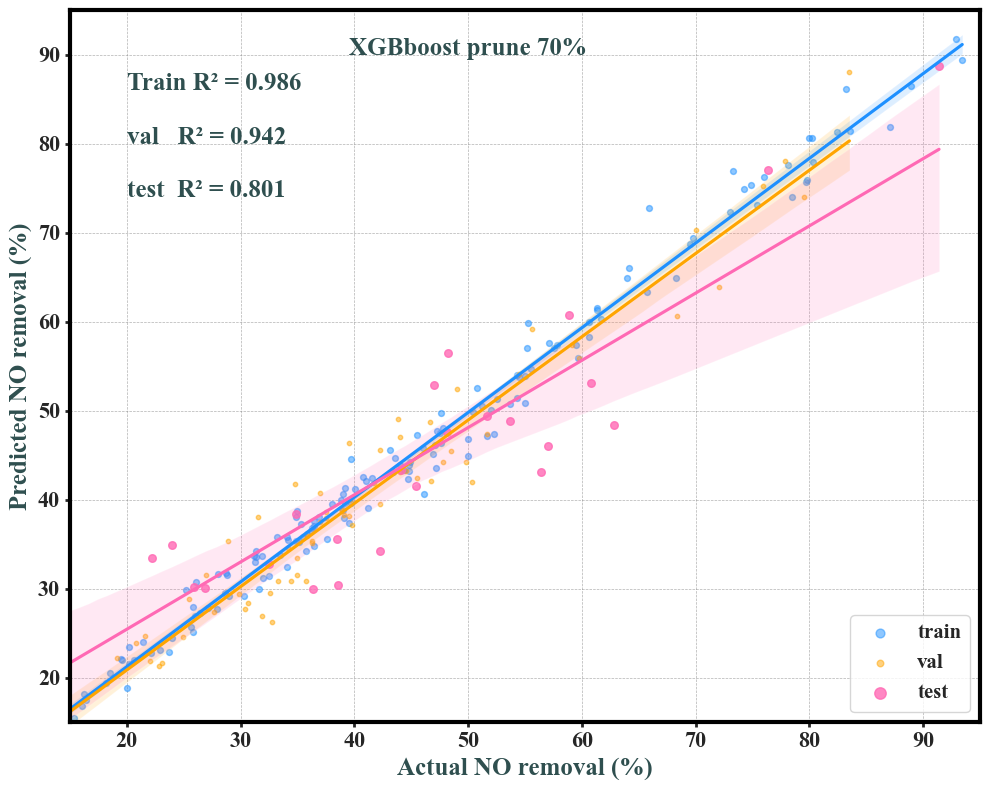

In [33]:
df_b = df.loc[remove_b[22]]
X_train_val = df_b.drop(columns=['NO(%)'])
y_train_val = df_b['NO(%)']
df_b_val = df.loc[b_test_70]
X_val = df_b_val.drop(columns=['NO(%)'])
y_val = df_b_val['NO(%)']
train_pred, val_pred = process_regressor(model[b],X_train_val,X_val,y_train_val,y_val)
_,test_pred = process_regressor(model[b],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('XGB Train 70%', y_train_val, train_pred)
model_performance_metrics('XGB val 30%', y_val, val_pred)
model_performance_metrics('XGB test', y_test, test_pred)
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "XGBboost prune 70%", actual_text='Actual NO removal (%)',test_lower=None,test_upper=None,pred_text='Predicted NO removal (%)',save=True)

cv train R2: -0.070 (+/- 0.307) 

cv train R2: -0.070 (+/- 0.307) 

GradientBoost Train 70% mse: 0.00001 | rmse: 0.00326 | mae: 0.00264 | mape: 0.66719 | smape: 0.66528 | r2: 0.99970

GradientBoost val 30% mse: 0.00145 | rmse: 0.03808 | mae: 0.02892 | mape: 7.38910 | smape: 7.30551 | r2: 0.93406

GradientBoost test mse: 0.00457 | rmse: 0.06764 | mae: 0.05623 | mape: 17.61105 | smape: 15.36585 | r2: 0.84610

测试图已保存：prune4\GradientBoost prune 70%.jpg


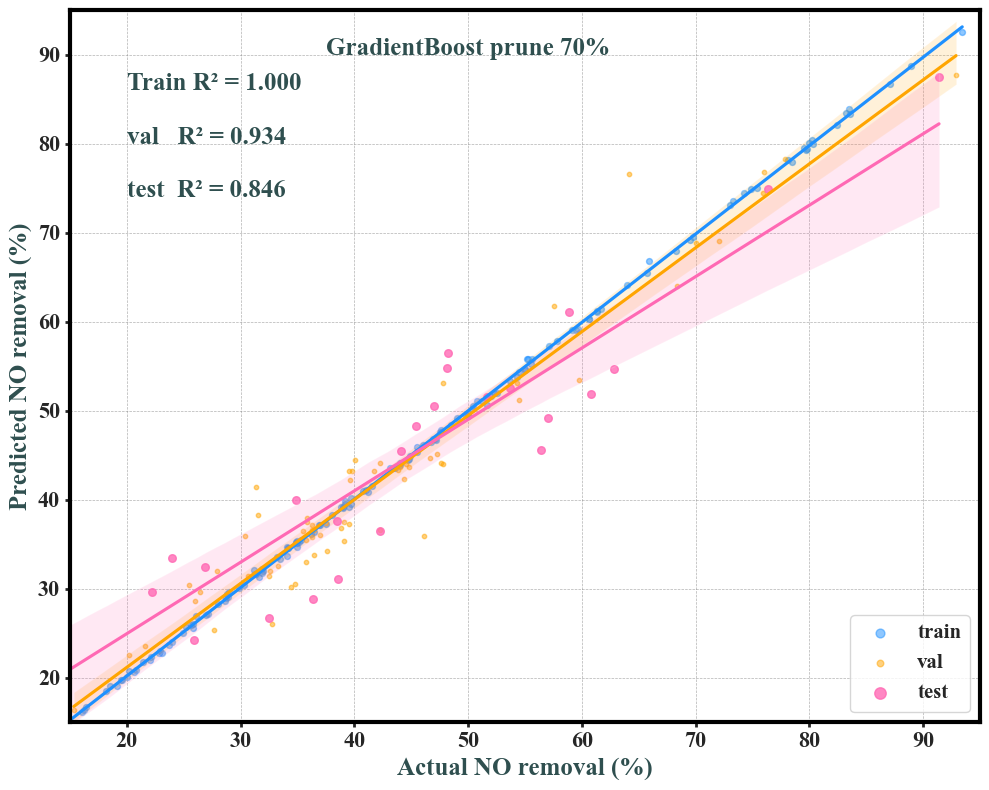

In [34]:
df_c = df.loc[remove_c[19]]
X_train_val = df_c.drop(columns=['NO(%)'])
y_train_val = df_c['NO(%)']
df_c_val = df.loc[c_test_70]
X_val = df_c_val.drop(columns=['NO(%)'])
y_val = df_c_val['NO(%)']
train_pred, val_pred = process_regressor(model[c],X_train_val,X_val,y_train_val,y_val,cv=True)
_,test_pred = process_regressor(model[c],X_train_val,X_test,y_train_val,y_test,cv=True)
model_performance_metrics('GradientBoost Train 70%', y_train_val, train_pred)
model_performance_metrics('GradientBoost val 30%', y_val, val_pred)
model_performance_metrics('GradientBoost test', y_test, test_pred)
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "GradientBoost prune 70%", actual_text='Actual NO removal (%)',test_lower=None,test_upper=None,pred_text='Predicted NO removal (%)',save=True)